In [3]:
# Setup
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from eeg_toolkit import load_config
from eeg_toolkit.rsa import load_all_rdms, compute_model_fits, square_to_vec
from eeg_toolkit.rsa_stats import test_model_fit, compare_model_fits, plot_model_fits

cfg = load_config('../../configs/eye_eeg_simul.yaml')

group_spatial = load_all_rdms(cfg, "cue", "spatial")
group_symbolic = load_all_rdms(cfg, "cue", "symbolic")
times = group_spatial["times"]

print("Setup OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, shape: (30, 462, 66)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, shape: (30, 462, 66)
Setup OK


In [4]:
# ── Reconstruct condition features ──
cond_names = sorted(group_spatial["condition_names"])
digits = np.array([int(c[1]) for c in cond_names])
positions = np.array([int(c[3]) for c in cond_names])

# ── Model RDMs ──
models = {
    "Position distance": np.abs(positions[:, None] - positions[None, :]).astype(float),
    "Digit distance":    np.abs(digits[:, None] - digits[None, :]).astype(float),
    "Position identity": (positions[:, None] != positions[None, :]).astype(float),
    "Digit identity":    (digits[:, None] != digits[None, :]).astype(float),
    "Left–right":        (np.array([0 if p <= 2 else 1 for p in positions])[:, None] !=
                          np.array([0 if p <= 2 else 1 for p in positions])[None, :]).astype(float),
    "Low–high":          (np.array([0 if d <= 2 else 1 for d in digits])[:, None] !=
                          np.array([0 if d <= 2 else 1 for d in digits])[None, :]).astype(float),
}

# ── Compute fits ──
print("=== SPATIAL BLOCK ===")
fits_spatial = compute_model_fits(group_spatial, models)

print("\n=== SYMBOLIC BLOCK ===")
fits_symbolic = compute_model_fits(group_symbolic, models)

=== SPATIAL BLOCK ===
Model fit summary (mean ± peak across time):
   Position distance        : mean r = 0.0127, peak r = 0.0816 at 0.391s
   Digit distance           : mean r = 0.0032, peak r = 0.0851 at 0.918s
   Position identity        : mean r = 0.0148, peak r = 0.0845 at 0.398s
   Digit identity           : mean r = -0.0018, peak r = 0.0406 at 0.918s
   Left–right               : mean r = 0.0120, peak r = 0.0759 at 0.289s
   Low–high                 : mean r = -0.0030, peak r = 0.0512 at 0.918s

=== SYMBOLIC BLOCK ===
Model fit summary (mean ± peak across time):
   Position distance        : mean r = 0.0108, peak r = 0.0950 at 0.676s
   Digit distance           : mean r = 0.0084, peak r = 0.0622 at 0.742s
   Position identity        : mean r = 0.0187, peak r = 0.0968 at 0.465s
   Digit identity           : mean r = -0.0018, peak r = 0.0483 at 0.625s
   Left–right               : mean r = 0.0088, peak r = 0.0547 at 0.676s
   Low–high                 : mean r = 0.0038, peak r = 0.

In [5]:
# ── Spatial block: test each model against zero ──
stats_spatial = {}
for name, fit_arr in fits_spatial.items():
    print(f"\n{'='*60}")
    stats_spatial[name] = test_model_fit(
        fit_arr, times,
        model_name=f"Spatial — {name}",
        n_permutations=10000,
    )


Test: Spatial — Position distance vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 10 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=15.981, std=8.758, 95th=32.315, 99th=47.268
  No significant clusters (alpha=0.05)


Test: Spatial — Digit distance vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 9 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=16.023, std=7.911, 95th=31.315, 99th=43.071
  1/9 significant clusters:
    Cluster 1: 0.910s – 0.949s, mass=34.45, p=0.0316


Test: Spatial — Position identity vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 17 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
   

In [6]:
# ── Symbolic block: test each model against zero ──
stats_symbolic = {}
for name, fit_arr in fits_symbolic.items():
    print(f"\n{'='*60}")
    stats_symbolic[name] = test_model_fit(
        fit_arr, times,
        model_name=f"Symbolic — {name}",
        n_permutations=10000,
    )


Test: Symbolic — Position distance vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 9 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=15.338, std=7.430, 95th=29.193, 99th=39.805
  1/9 significant clusters:
    Cluster 1: 0.539s – 0.594s, mass=39.53, p=0.0107


Test: Symbolic — Digit distance vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 9 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
    permutation 8000/10000
    permutation 10000/10000

  Null distribution: mean=15.132, std=7.378, 95th=29.246, 99th=40.070
  No significant clusters (alpha=0.05)


Test: Symbolic — Position identity vs zero
  30 subjects, threshold t=2.05, 10000 permutations
  Found 13 clusters in real data
    permutation 2000/10000
    permutation 4000/10000
    permutation 6000/10000
 

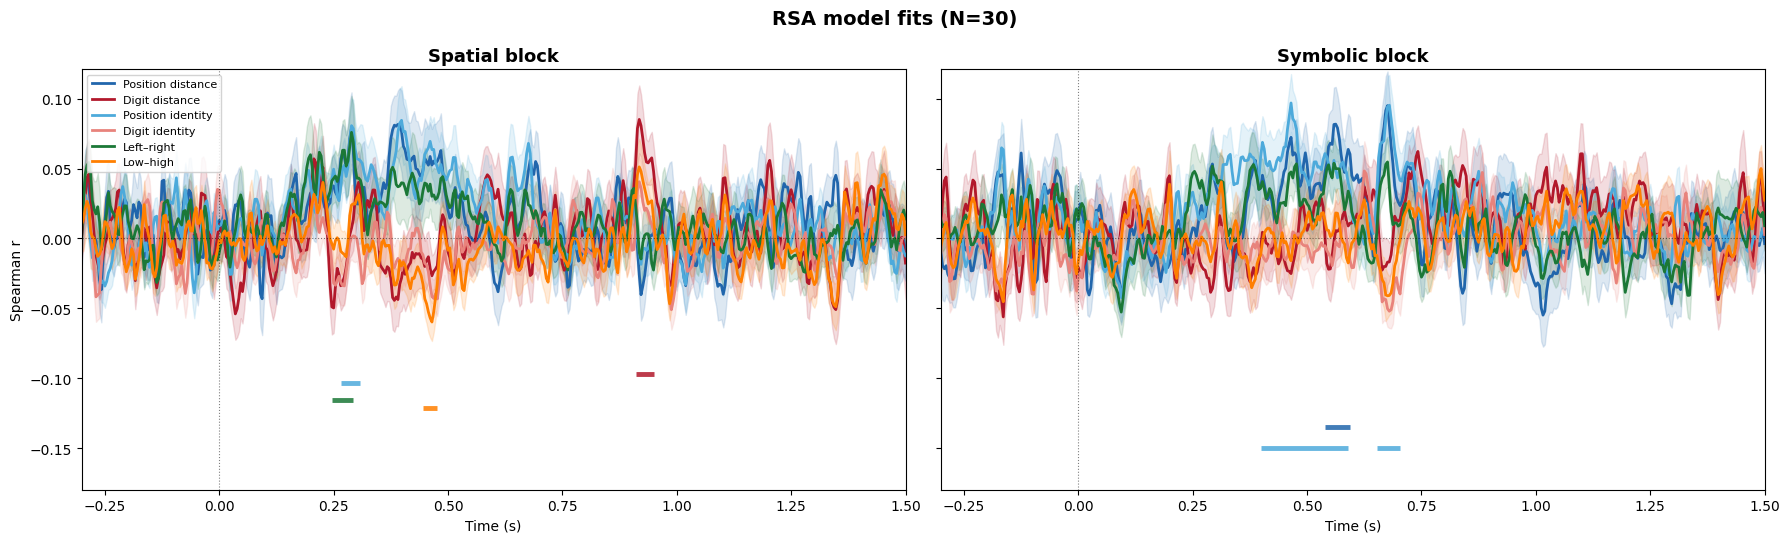

In [7]:
colors = {
    "Position distance": "#2166AC",
    "Digit distance":    "#B2182B",
    "Position identity": "#4DAADB",
    "Digit identity":    "#E8837C",
    "Left–right":        "#1B7837",
    "Low–high":          "#FF7F00",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharey=True)

for ax, fits, stats, block_name in [
    (axes[0], fits_spatial, stats_spatial, "Spatial block"),
    (axes[1], fits_symbolic, stats_symbolic, "Symbolic block"),
]:
    plot_model_fits(fits, times, stats_dict=stats, colors=colors,
                    title=block_name)
    # plot_model_fits creates its own figure, so let's do it manually here
    plt.close()  # close the auto-created figure

    n_subj = next(iter(fits.values())).shape[0]
    for name, fit_arr in fits.items():
        mean_r = np.nanmean(fit_arr, axis=0)
        sem_r = np.nanstd(fit_arr, axis=0) / np.sqrt(n_subj)
        col = colors[name]
        ax.plot(times, mean_r, color=col, lw=2, label=name)
        ax.fill_between(times, mean_r - sem_r, mean_r + sem_r,
                        color=col, alpha=0.15)

    ax.axhline(0, color="k", lw=0.8, ls=":", alpha=0.5)
    ax.axvline(0, color="k", lw=0.8, ls=":", alpha=0.5)

    # Significance bars
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    bar_gap = y_range * 0.03

    for mi, (name, results) in enumerate(stats.items()):
        sig_clusters = results.get("significant_clusters", [])
        col = colors[name]
        y_pos = y_min - bar_gap * (mi + 1)
        for cluster in sig_clusters:
            t0 = times[cluster["start_idx"]]
            t1 = times[cluster["end_idx"]]
            ax.plot([t0, t1], [y_pos, y_pos], color=col, lw=3.5,
                    solid_capstyle="butt", alpha=0.85)

    new_ymin = y_min - bar_gap * (len(stats) + 1)
    ax.set_ylim(bottom=new_ymin)
    ax.set_xlim(times[0], times[-1])
    ax.set_xlabel("Time (s)")
    ax.set_title(block_name, fontsize=13, fontweight="bold")

axes[0].set_ylabel("Spearman r")
axes[0].legend(fontsize=8, loc="upper left", framealpha=0.85)

fig.suptitle(f"RSA model fits (N={n_subj})", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()